# **Llama 3 Chatbot**

In [ ]:
!pip install -q -U gradio transformers accelerate torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.26.0+cu130 requires torch==2.11.0, but you have torch 2.14.1 which is incompatible.


- Gradio will be used here for the sake of cell web page kind.
- Huggingface library: Transformer: Models like Llama

In [ ]:
import os
from threading import Thread # You can do two things at once.

import gradio as gr
import torch
from transformers import (
    AutoModelForCausalLM, # its like a LLM primary use cases is what? Mostly we predict next words.... It is mostly sees the previous words.
    AutoTokenizer,
    TextIteratorStreamer,
)

try:
    import spaces  # only available on Hugging Face Spaces
    gpu_decorator = spaces.GPU(duration=120)
except ImportError:
    gpu_decorator = lambda fn: fn  # no-op outside Spaces

assert torch.cuda.is_available(), "No GPU found. Switch the runtime to GPU first."
print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


## **Authenticate With HuggingFace**

In [ ]:
from huggingface_hub import login

HF_TOKEN = os.environ.get("HF_TOKEN", None)

if HF_TOKEN:
    login(token=HF_TOKEN)
else:
    login()  # interactive prompt in the notebook

## **UI Description**

In [ ]:
DESCRIPTION = '''
<div>
<h1 style="text-align: center;">Local Chatbot Making Using OpenCourse LLM/h1>
<p>This uses an open source Large Language Model called <a href="https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct"><b>Llama3-3B</b></a></p>
</div>
'''

## **Load tokenizer and model**

Downloads ~6 GB of weights on first run and uses ~6.5 GB of GPU memory in fp16.

- `device_map="auto"` puts the weights straight onto the GPU.
- `low_cpu_mem_usage=True` avoids loading the full model into CPU RAM first.

**Want it even lighter?** Set `MODEL_ID` to `"meta-llama/Llama-3.2-1B-Instruct"` (~2.5 GB, faster but weaker answers; accept its license on Hugging Face too).

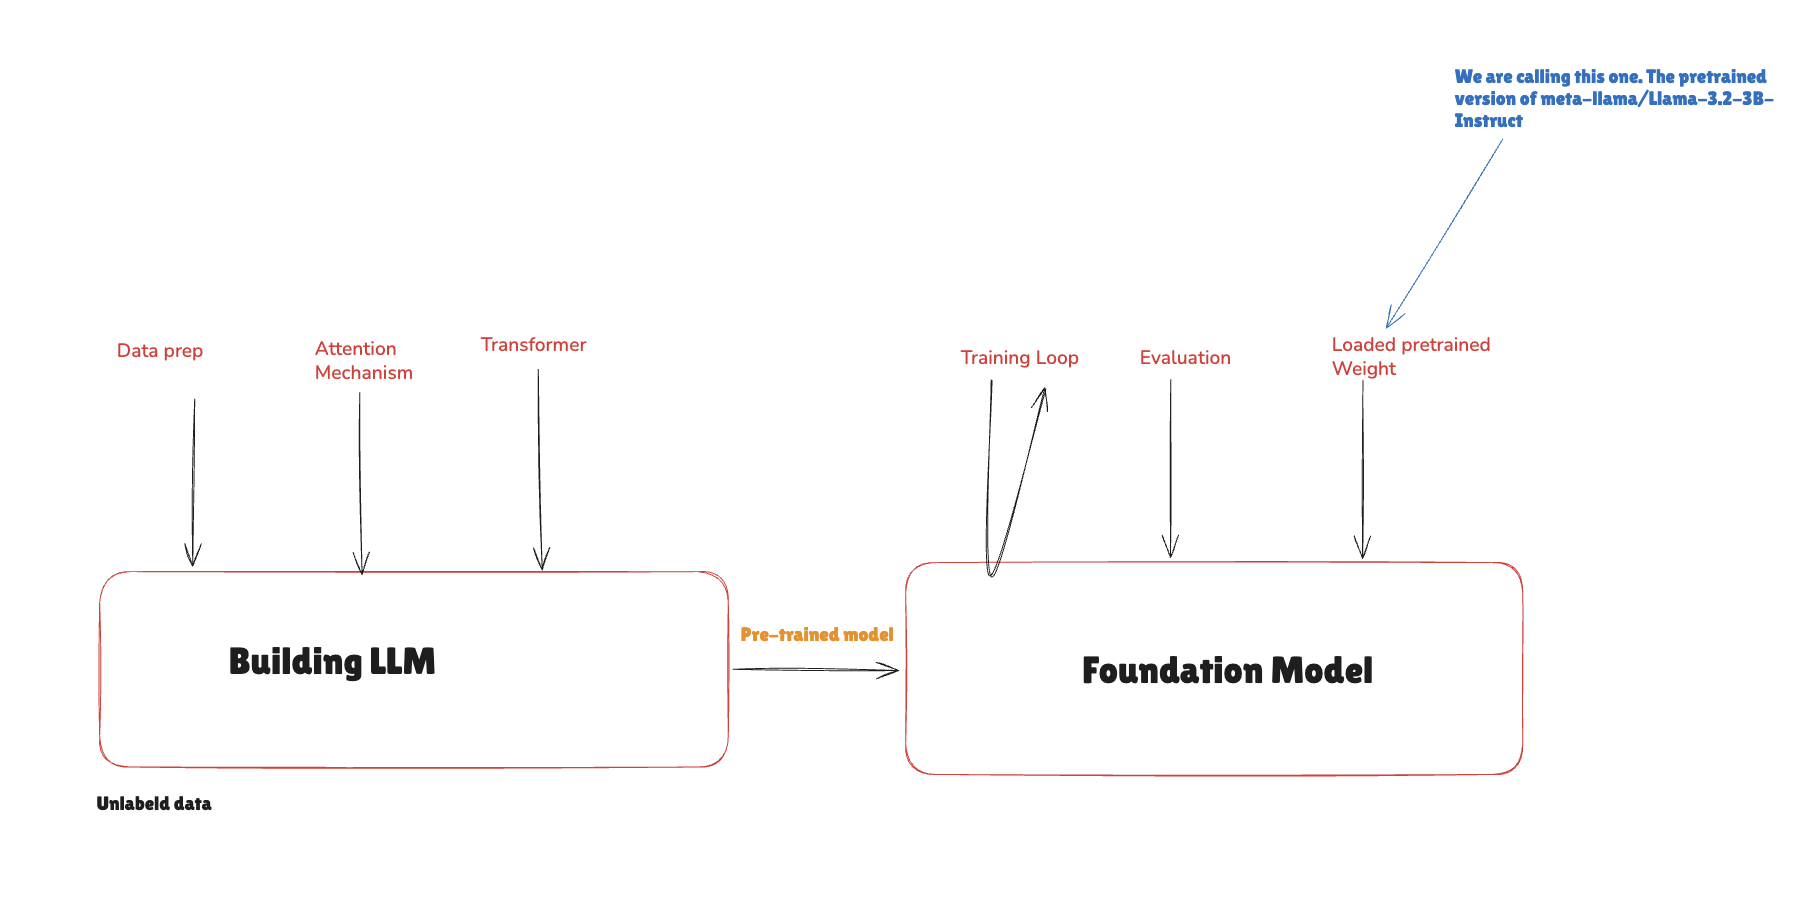

In [ ]:
# Upgrade transformers, accelerate, and huggingface_hub to make sure compatible versions are used.
# After running this cell, please go to 'Runtime' -> 'Restart session' to apply the changes.
!pip install -U --upgrade-strategy eager transformers accelerate huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.4/110.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 123.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31

In [ ]:
MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"   # or "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, #Wights
    dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
model.eval()

print(f"Model on: {model.device}")
print(f"GPU memory used: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

terminators = [
    tokenizer.eos_token_id,
    tokenizer.convert_tokens_to_ids("<|eot_id|>"),
]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model on: cuda:0
GPU memory used: 6.4 GB


## **Generation function**

Builds the chat history, applies the Llama 3 chat template, and streams tokens back. Handles both Gradio history formats (`[user, assistant]` pairs and `{"role", "content"}` dicts) so it works across Gradio versions.

In [ ]:
@gpu_decorator
def llama_generation(message: str,
                     history: list,
                     temperature: float,
                     max_new_tokens: int):
    """
    Passes input, converts in tokens, generates with ids and streams
    the text out.
    """
    conversation = []
    for turn in history: # This where I can say memory is not there LLM and it will give me bad result as output every continious conversation.
    # So We hard-coded here the merory sid eof it.
        if isinstance(turn, dict):
            conversation.append({"role": turn["role"], "content": turn["content"]})
        else:                       # legacy [user, assistant] pairs
            user, assistant = turn
            conversation.extend([
                {"role": "user", "content": user},
                {"role": "assistant", "content": assistant},
            ])
    conversation.append({"role": "user", "content": message})

    # Newer transformers return a dict (input_ids + attention_mask), not a bare tensor.
    inputs = tokenizer.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)

    streamer = TextIteratorStreamer(
        tokenizer, timeout=60.0, skip_prompt=True, skip_special_tokens=True
    )

    generate_kwargs = dict(
        **inputs,
        streamer=streamer,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        eos_token_id=terminators,
    )
    # Greedy decoding when temperature is 0 (sampling with temperature=0 crashes).
    if temperature == 0:
        generate_kwargs["do_sample"] = False
        generate_kwargs.pop("temperature")

    t = Thread(target=model.generate, kwargs=generate_kwargs)
    t.start()

    outputs = []
    for text in streamer:
        outputs.append(text)
        yield "".join(outputs)

The model currently has no memory. Everytime you will be sending a message, the whole conversation can sent again.


```
[{"role": "user", "content", "Hi"},

 {"role": "assistant(Bot)", "content", "Hello"},

 {"role": "user", "content", "What is today's date?"},]
```




## **Quick test**

Runs one prompt without the UI to confirm the model works.

**Optional**

You can it or you just ignore it.

In [ ]:
response = ""
for partial in llama_generation("Who is PM of india?", [], 0.7, 200):
    response = partial
print(response)

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


As of my knowledge cutoff in 2023, the Prime Minister of India is Narendra Modi. He has been in office since May 2014 and is currently serving his third term. However, please note that this information may have changed since my knowledge cutoff date.


## **Build the Gradio interface**

"Max new tokens" is capped at 1024 to keep the KV cache within a T4's memory during long chats.

UI- User interface.

In [ ]:
chatbot = gr.Chatbot(height=600, label="Llama 3.2")

with gr.Blocks(fill_height=True) as demo:
    gr.Markdown(DESCRIPTION)
    gr.ChatInterface(
        fn=llama_generation,
        chatbot=chatbot,
        fill_height=True,
        additional_inputs_accordion=gr.Accordion(label="⚙️ Parameters", open=False, render=False),
        additional_inputs=[
            gr.Slider(minimum=0, maximum=1, step=0.1, value=0.95,
                      label="Temperature", render=False),
            gr.Slider(minimum=128, maximum=1024, step=1, value=512,
                      label="Max new tokens", render=False),
        ],
        examples=[
            ["Make a poem of batman inside willy wonka"],
            ["How can you a burrito with just flour?"],
            ["How was saturn formed in 3 sentences"],
            ["How does the frontal lobe effect playing soccer"],
        ],
        cache_examples=False,
    )

## **Launch**

`share=True` creates a public link (needed in Colab). `debug=True` keeps the cell running and shows errors; stop the cell to shut the app down.

In [ ]:
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c11564fa57070a83db.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
